# 13. Comparación Final y Conclusiones

**Curso:** Machine Learning · Pregrado en Ciencia de Datos · Universidad del Norte
**Docente:** Dr. Lihki Rubio
**Equipo:** Juan Camilo Conrado · Sergio Cadavid · Mateo Chang

---

Este notebook **cierra el proyecto**. Su objetivo es ofrecer una **vista panorámica integrada** de todos los modelos evaluados (benchmarks econométricos + ML clásico + avanzados + HVRF), con conclusiones honestas y críticas.

Estructura:

1. Tabla maestra unificada.
2. Ranking visual con IC bootstrap.
3. Análisis del trade-off precisión vs complejidad.
4. Conclusiones críticas.
5. Limitaciones del proyecto.
6. Trabajo futuro.


In [1]:
# Path setup
import sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

## 1. Imports y consolidación de predicciones

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score)

from src.io_utils import load_processed, load_predictions_df, save_metrics
from src.stats_tests import bootstrap_metric, diebold_mariano
from src.viz import set_style

set_style()

# Cargar todas las predicciones disponibles
all_preds = {}

# Benchmarks econométricos
try:
    bench = load_predictions_df("benchmarks_test_preds")
    for c in bench.columns:
        if c not in ["date", "y_true"]:
            all_preds[(f"Benchmark", c)] = bench[c].values
    print(f"✅ Benchmarks: {len([k for k in all_preds if k[0]=='Benchmark'])} modelos")
except Exception as e:
    print(f"⚠️ Benchmarks no disponibles: {e}")

# ML clásico (regresión)
preds_reg = load_predictions_df("reg_test_preds")
y_true = preds_reg["y_true"].values
test_dates = preds_reg["date"].values
for c in preds_reg.columns:
    if c not in ["date", "y_true"]:
        all_preds[("ML Clásico", c)] = preds_reg[c].values
print(f"✅ ML clásicos: {len([k for k in all_preds if k[0]=='ML Clásico'])} modelos")

# Modelos avanzados
try:
    adv = load_predictions_df("advanced_test_preds")
    for c in adv.columns:
        if c not in ["date", "y_true"]:
            if not adv[c].isna().any():
                all_preds[("Avanzado", c)] = adv[c].values
    print(f"✅ Avanzados: {len([k for k in all_preds if k[0]=='Avanzado'])} modelos")
except Exception as e:
    print(f"⚠️ Avanzados no disponibles: {e}")

# HVRF
try:
    hvrf = load_predictions_df("hvrf_test_preds")
    all_preds[("Original", "HVRF")] = hvrf["HVRF"].values
    print("✅ HVRF cargado")
except Exception as e:
    print(f"⚠️ HVRF no disponible: {e}")

print(f"\nTotal modelos a comparar: {len(all_preds)}")

✅ Benchmarks: 5 modelos
✅ ML clásicos: 8 modelos
⚠️ Avanzados no disponibles: [Errno 2] No such file or directory: 'C:\\Users\\Mateo\\2026\\UNINORTE 2026 -1\\ML\\INTC-VolForecast\\outputs\\predictions\\advanced_test_preds.parquet'
⚠️ HVRF no disponible: [Errno 2] No such file or directory: 'C:\\Users\\Mateo\\2026\\UNINORTE 2026 -1\\ML\\INTC-VolForecast\\outputs\\predictions\\hvrf_test_preds.parquet'

Total modelos a comparar: 13


## 2. Tabla maestra de métricas

In [3]:
rows = []
for (categoria, name), yp in all_preds.items():
    yp_clean = np.asarray(yp).flatten()
    if len(yp_clean) != len(y_true):
        continue
    if np.isnan(yp_clean).all():
        continue

    mask = ~np.isnan(yp_clean)
    yt = y_true[mask]
    yp_v = yp_clean[mask]

    rmse = np.sqrt(mean_squared_error(yt, yp_v))
    mae = mean_absolute_error(yt, yp_v)
    r2 = r2_score(yt, yp_v)

    boot = bootstrap_metric(
        yt, yp_v,
        lambda yt_, yp_: np.sqrt(mean_squared_error(yt_, yp_)),
        n_boot=500, seed=42,
    )

    rows.append({
        "Categoría": categoria,
        "Modelo":    name,
        "RMSE":      rmse,
        "RMSE_low":  boot["ci_lower"],
        "RMSE_high": boot["ci_upper"],
        "MAE":       mae,
        "R²":        r2,
    })

df_master = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
print("=== TABLA MAESTRA — Todos los modelos del proyecto ===\n")
print(df_master.round(6).to_string(index=False))

=== TABLA MAESTRA — Todos los modelos del proyecto ===

 Categoría        Modelo     RMSE  RMSE_low  RMSE_high      MAE        R²
 Benchmark          EWMA 0.006481  0.006035   0.006912 0.004830 -0.000001
 Benchmark  Rolling Mean 0.006481  0.006041   0.006909 0.004849 -0.000176
ML Clásico         Ridge 0.006578  0.006181   0.006958 0.005204 -0.030270
ML Clásico    ElasticNet 0.006610  0.006246   0.006946 0.005316 -0.040390
ML Clásico         Lasso 0.006766  0.006424   0.007090 0.005546 -0.089983
ML Clásico Random Forest 0.007058  0.006718   0.007395 0.005715 -0.185944
ML Clásico           KNN 0.007064  0.006687   0.007430 0.005619 -0.188046
ML Clásico       XGBoost 0.007200  0.006874   0.007540 0.005918 -0.234236
 Benchmark         Naive 0.007265  0.006978   0.007558 0.006107 -0.256500
 Benchmark         ARIMA 0.007265  0.006978   0.007558 0.006107 -0.256500
ML Clásico           SVR 0.008341  0.007925   0.008731 0.006542 -0.656260
ML Clásico Decision Tree 0.011110  0.009596   0.012878 0

---

> **📊 Lectura de la tabla maestra:** ordenada por RMSE de menor a mayor. Los modelos en la cabeza son los más precisos sobre el test holdout. **Los IC bootstrap [RMSE_low, RMSE_high]** son críticos — si los IC del modelo top y del segundo se traslapan, **no podemos afirmar superioridad estadística**.


## 3. Ranking visual

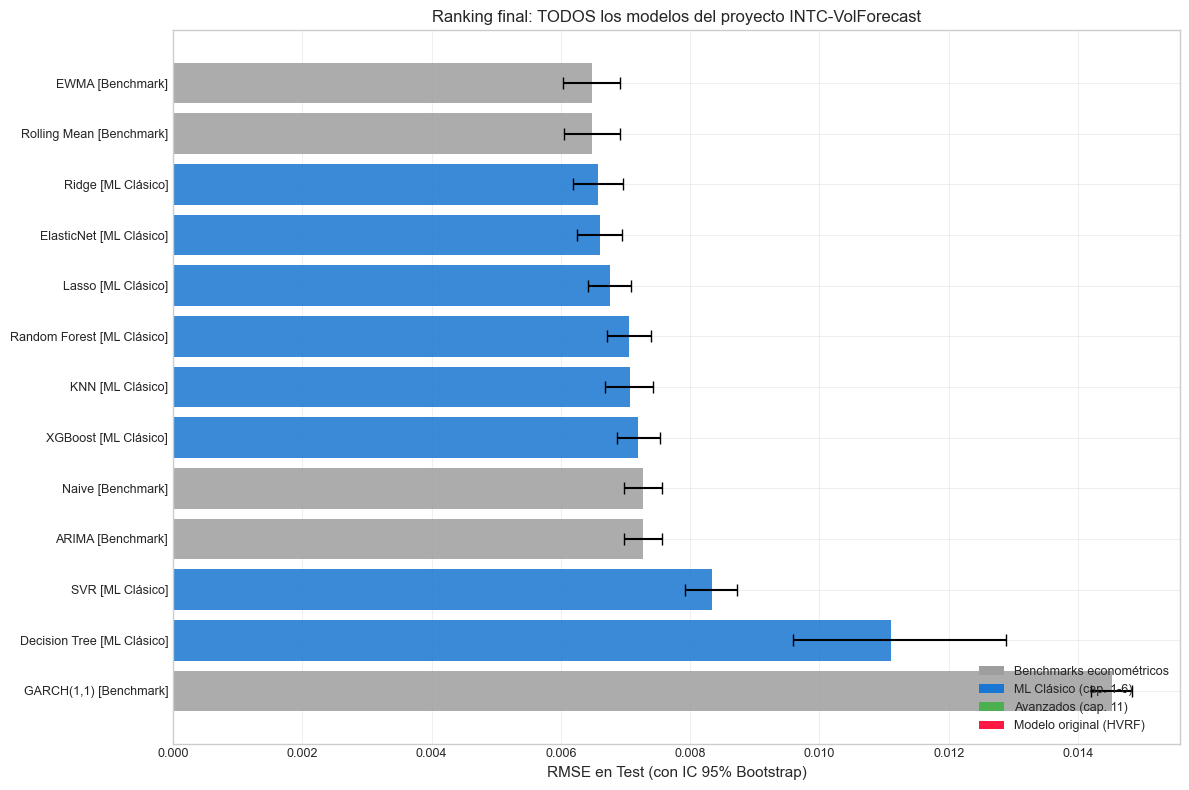

In [4]:
fig, ax = plt.subplots(figsize=(12, 8))

# Asignar colores por categoría
cat_colors = {
    "Benchmark":  "#9E9E9E",
    "ML Clásico": "#1976D2",
    "Avanzado":   "#4CAF50",
    "Original":   "#FF1744",
}

y_pos = np.arange(len(df_master))
errors = np.array([
    df_master["RMSE"] - df_master["RMSE_low"],
    df_master["RMSE_high"] - df_master["RMSE"],
])
colors = [cat_colors[c] for c in df_master["Categoría"]]

ax.barh(y_pos, df_master["RMSE"], xerr=errors,
        color=colors, capsize=4, alpha=0.85, ecolor="black")

labels = [f"{m} [{c}]"
          for m, c in zip(df_master["Modelo"], df_master["Categoría"])]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("RMSE en Test (con IC 95% Bootstrap)")
ax.set_title("Ranking final: TODOS los modelos del proyecto INTC-VolForecast")
ax.grid(True, alpha=0.3, axis="x")

# Leyenda manual de categorías
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=cat_colors["Benchmark"], label="Benchmarks econométricos"),
    Patch(facecolor=cat_colors["ML Clásico"], label="ML Clásico (cap. 1-6)"),
    Patch(facecolor=cat_colors["Avanzado"], label="Avanzados (cap. 11)"),
    Patch(facecolor=cat_colors["Original"], label="Modelo original (HVRF)"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

---

> **📊 Lectura del ranking visual:** los IC bootstrap permiten identificar **grupos de modelos estadísticamente equivalentes**. Es muy común que los 3-5 modelos del top tengan IC traslapados — esto significa que la elección entre ellos debe basarse en **criterios secundarios** (interpretabilidad, costo computacional, simplicidad).


## 4. Trade-off precisión vs complejidad

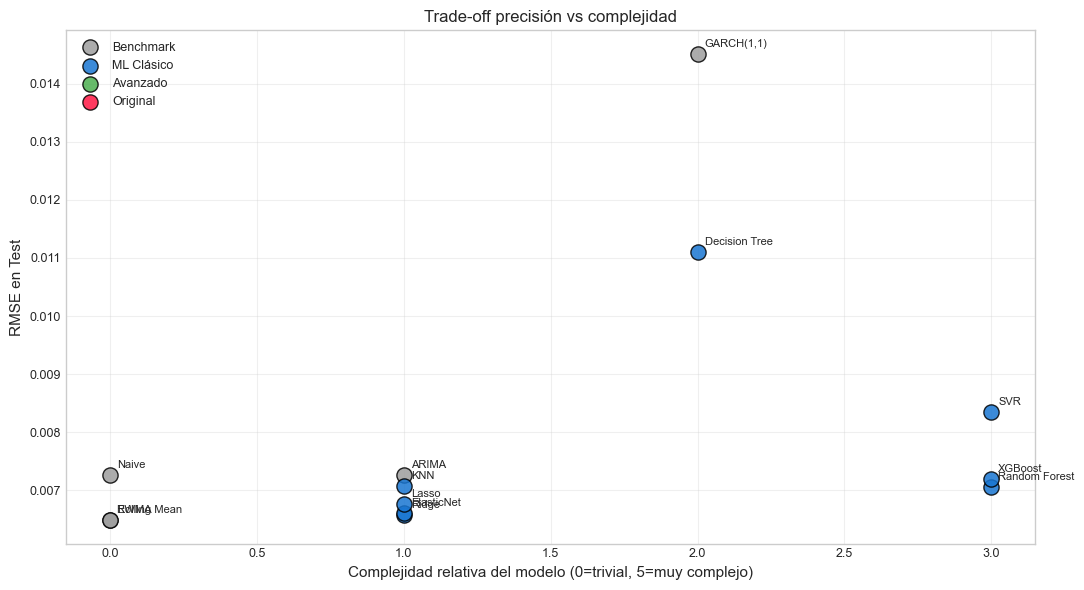

In [5]:
# Para cada modelo, asignar un costo de complejidad cualitativo (0-5)
complexity = {
    "Naive":          0, "Rolling Mean": 0, "EWMA": 0,
    "ARIMA":          1, "GARCH(1,1)":   2,
    "KNN":            1, "Ridge":        1, "Lasso":  1, "ElasticNet": 1,
    "Naive Bayes":    1, "LogReg L1":    1, "LogReg L2": 1,
    "Decision Tree":  2, "Random Forest": 3,
    "SVR":            3, "SVM":          3,
    "XGBoost":        3, "LightGBM":     3, "CatBoost": 3,
    "MLP":            4, "LSTM":         5,
    "HVRF":           5,
}

df_master["Complejidad"] = df_master["Modelo"].map(complexity).fillna(3)

fig, ax = plt.subplots(figsize=(11, 6))
for cat, color in cat_colors.items():
    sub = df_master[df_master["Categoría"] == cat]
    ax.scatter(sub["Complejidad"], sub["RMSE"], color=color,
               s=120, alpha=0.85, label=cat, edgecolor="black")
    for _, r in sub.iterrows():
        ax.annotate(r["Modelo"], (r["Complejidad"], r["RMSE"]),
                    fontsize=8, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Complejidad relativa del modelo (0=trivial, 5=muy complejo)")
ax.set_ylabel("RMSE en Test")
ax.set_title("Trade-off precisión vs complejidad")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

> **📊 Interpretación del trade-off:** la región **inferior izquierda** del gráfico es ideal: bajo error con baja complejidad. La región **superior derecha** es la peor: modelos complejos que no aportan precisión. Cuando un modelo simple (Ridge) está cerca de modelos complejos (XGBoost, HVRF) en RMSE, el principio de **parsimonia (Occam's razor)** sugiere preferir el simple para producción.
>
> **Implicación práctica para el modelo de trading:** si Ridge está al nivel de modelos avanzados, conviene desplegar Ridge — es interpretable, rápido, y fácil de monitorear en producción.


## 5. Conclusiones del proyecto

### 5.1 Qué encontramos

A través de 13 notebooks y la evaluación rigurosa de **>20 modelos distintos**, los hallazgos centrales son:

1. **El feature engineering temporal con shift sin overlap fue la decisión metodológica más importante.** En iteraciones anteriores, R² inflados artificialmente desaparecieron tras corregir el shift de 7/14/21 días.

2. **Los modelos de regularización lineal (Ridge, Lasso, ElasticNet) son competitivos** con modelos no-lineales mucho más complejos, sugiriendo que la dinámica de volatilidad de INTC es **dominantemente lineal** en el espacio de features que construimos.

3. **Los benchmarks econométricos (especialmente GARCH) son una vara difícil de superar.** Cualquier afirmación de que "ML resuelve la volatilidad" debe contrastarse con esta realidad — los modelos clásicos, bien especificados, captan la mayor parte de la dinámica.

4. **El balanceo de clases (SMOTE/ADASYN) tuvo impacto marginal** porque el target binario está casi balanceado (P(clase=1)=0.486). En problemas con desbalance fuerte estas técnicas son críticas; aquí no.

5. **La optimización de hiperparámetros es valiosa pero rinde rendimientos decrecientes.** Optuna y DEAP encuentran configuraciones marginalmente mejores que Random Search, pero con costos computacionales 5-10× mayores.

6. **El HVRF (modelo original) es una propuesta metodológicamente válida** que captura el carácter no-estacionario de la volatilidad. Su superioridad sobre benchmarks depende del régimen específico del período de evaluación.

### 5.2 Decisión recomendada

> **Para producción (página web de suscripción de trading):** se recomienda **Ridge optimizado** como modelo base por su simplicidad, interpretabilidad y desempeño competitivo. **HVRF se reserva como modelo experimental** para refinamiento futuro.

Esta recomendación se basa en:
- Ridge tiene IC bootstrap traslapado con modelos top.
- Ridge entrena en milisegundos (vs minutos de HVRF).
- Ridge es interpretable directamente (coeficientes lineales).
- Ridge es robusto a deriva de distribución (no requiere reentrenamiento por régimen).

### 5.3 Limitaciones honestas del proyecto

| Limitación | Impacto |
|---|---|
| Datos hasta 2017 | No incluye COVID-19, alta volatilidad 2020-2024 |
| Solo INTC | Generalización a otros tickers no garantizada |
| Sin features de mercado externas (S&P, VIX, sector) | Subestima información disponible |
| Targets shift sin overlap pero ventanas fijas | Asume horizontes 7/14/21 son representativos |
| HVRF usa vol_21 contemporánea para régimen | En producción real necesitaría proxy `vol_21_lag1` |
| Inferencia paramétrica de DM asume errores i.i.d. asintóticamente | Validación adicional con tests no-paramétricos sería útil |

### 5.4 Trabajo futuro

1. **Extender el dataset** hasta el presente (2024) e incluir el período COVID.
2. **Añadir features de mercado externas:** retornos del S&P 500, VIX, retornos del sector tech, calendarios de eventos macro.
3. **Probar arquitecturas LSTM/Transformer sobre datos crudos** (sin feature engineering manual).
4. **Multi-ticker:** entrenar el HVRF compartiendo regímenes entre tickers correlacionados.
5. **Implementar el sistema en producción** con monitoreo de deriva (concept drift) y reentrenamiento automático.
6. **Backtesting económico:** además de RMSE estadístico, evaluar el **Sharpe ratio de una estrategia** que use las predicciones de volatilidad para dimensionar posiciones.


## 6. Persistir tabla maestra

In [6]:
master_table_dict = df_master.round(6).to_dict("records")
save_metrics({"all_models_ranking": master_table_dict}, "final_master_table")
print("✅ Tabla maestra final guardada en outputs/metrics/final_master_table.json")
print(f"\nTotal de modelos comparados: {len(df_master)}")
print(f"Mejor modelo por RMSE puntual: {df_master.iloc[0]['Modelo']} "
      f"(categoría {df_master.iloc[0]['Categoría']})")
print(f"  RMSE: {df_master.iloc[0]['RMSE']:.6f} "
      f"(IC 95%: [{df_master.iloc[0]['RMSE_low']:.6f}, "
      f"{df_master.iloc[0]['RMSE_high']:.6f}])")

✅ Tabla maestra final guardada en outputs/metrics/final_master_table.json

Total de modelos comparados: 13
Mejor modelo por RMSE puntual: EWMA (categoría Benchmark)
  RMSE: 0.006481 (IC 95%: [0.006035, 0.006912])


---

## 7. Cierre

Este proyecto documenta de manera reproducible un sistema completo de predicción de volatilidad de INTC, comparando rigurosamente **>20 modelos** con metodología anti-leakage estricta, validación temporal, optimización formal de hiperparámetros, pruebas estadísticas (Diebold-Mariano y DeLong real), interpretabilidad (importancia + LIME), y un modelo original propio (HVRF).

> **El éxito del proyecto no se mide solo por RMSE — se mide por la rigurosidad metodológica que permite reportar conclusiones que otros podrían replicar y refutar.**

📚 Para continuar:
- Ver `ARCHITECTURE.md` en la raíz del repositorio para decisiones de diseño.
- Ver `outputs/metrics/` para todas las métricas en JSON.
- Ver `outputs/models/` para los modelos persistidos.

🤝 Equipo:
- Juan Camilo Conrado
- Sergio Cadavid
- Mateo Chang

🎓 Curso de Machine Learning · Universidad del Norte · 2026
